In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

games = pd.read_csv("data/games_processed.csv")

In [43]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree


from sklearn.metrics import mean_squared_error, r2_score

In [44]:
# 2. Feature Selection

features = [
    "price",
    "metacritic_score",
    "game_type",
    "dlc_count"  # Ensure this was added in EDA step
]

target = "success_index"

ml_data = games[features + [target]].dropna()

X = ml_data[features]
y = ml_data[target]

print(f"Training with features: {features}")

Training with features: ['price', 'metacritic_score', 'game_type', 'dlc_count']


### **Feature Selection & Data Preparation**
**Objective:** Prepare the dataset for *predictive* modeling.

**Strategy:**
To build a valid predictive model, we must only use features that are available *before* a game is released or that describe the game's characteristics (independent variables). We specifically exclude `log_owners` and `review_score` because they are used to calculate the target variable (`success_index`), and including them would cause Target Leakage.

**Selected Features:**
* `game_type`: The category of the game (Singleplayer / Multiplayer / Hybrid).
* `metacritic_score`: The critical reception score (Quality).
* `price`: The release price of the game.
* `dlc_count`: The number of downloadable content packs (Post-launch support).

**Target Variable:**
* `success_index`: A composite metric of sales volume and user ratings.

In [ ]:
# 3. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train–Test Split and Pipeline Construction

The dataset was divided into training and testing subsets to ensure unbiased model evaluation.
This approach prevents information leakage and ensures that reported performance reflects generalization.
Such separation is fundamental for the validity of predictive modeling results.

In [46]:

# 4. Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["game_type"])
    ],
    remainder="passthrough"
)

In [47]:

# 5. Linear Regression Model

linear_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [48]:
dt_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=50,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [49]:

# 6. Random Forest Model

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

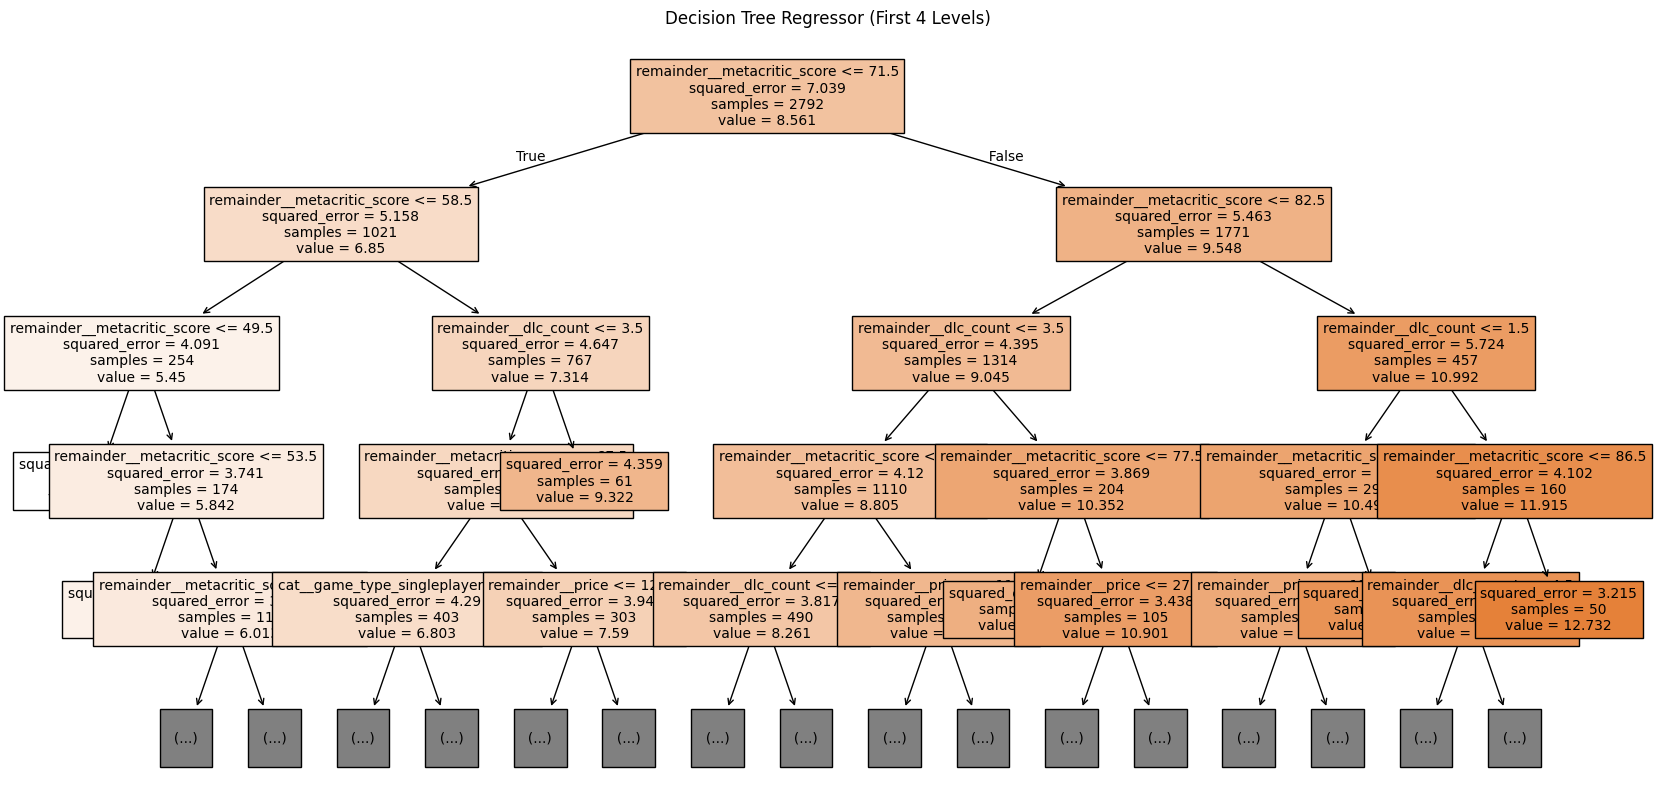

In [50]:
# Extract trained decision tree from the pipeline
dt = dt_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = (
    dt_model.named_steps["preprocess"]
    .get_feature_names_out()
)

# Plot a shallow version of the tree for interpretability
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=feature_names,
    filled=True,
    max_depth=4,   # limit depth to keep it readable
    fontsize=10
)

plt.title("Decision Tree Regressor (First 4 Levels)")
plt.show()

# Decision Tree Visualization

The visualization illustrates the sequential decision rules learned by the model.
Early splits highlight the most influential predictors of the success index.
This improves interpretability and supports transparent analysis of model behavior.

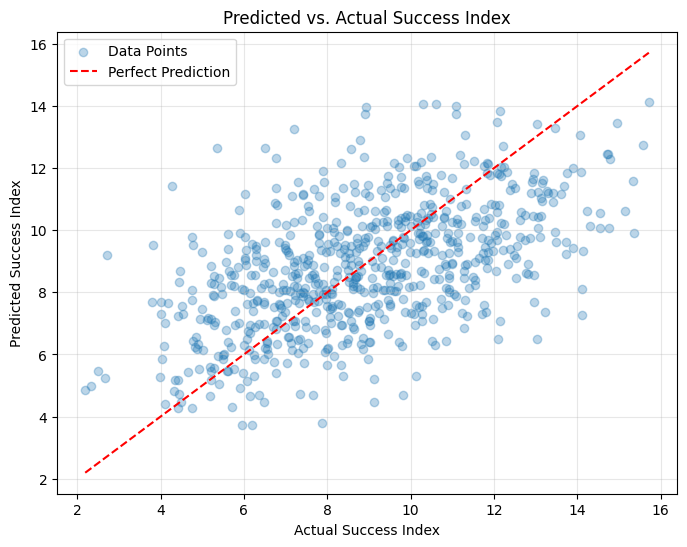

In [55]:
# 8. Actual vs Predicted Plot (Random Forest)
rf_preds = rf_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.3, label='Data Points')

# Add a "Perfect Prediction" line (y = x)
min_val = min(y_test.min(), rf_preds.min())
max_val = max(y_test.max(), rf_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Success Index")
plt.ylabel("Predicted Success Index")
plt.title("Predicted vs. Actual Success Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("actual_vs_predicted.png") # Save for report

### **Data Interpretation: Predicted vs. Actual**

This scatter plot compares the model's predictions (Y-axis) against the real success index (X-axis).

* **The Red Line:** This represents perfect prediction. If the model were 100% accurate, all blue dots would sit exactly on this red dashed line.
* **The Spread:** The dots are scattered loosely around the trend rather than forming a tight line.
    * **Observation:** The model generally identifies the *trend* (higher actual success leads to higher predicted success), but there is significant variance.
    * **Implication:** The model is good at distinguishing "good" games from "bad" games on average, but it cannot pinpoint the *exact* success score for any specific game.
* **Outliers:** Some games with very high actual success (far right) are predicted to be much lower (below the line). This means the model tends to **underestimate** mega-hits, likely because viral success depends on factors not present in the data (like marketing or streamer hype).

In [56]:
models = {
    "Linear Regression": linear_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results.append([name, rmse, r2])

results_df = pd.DataFrame(
    results, columns=["Model", "RMSE", "R²"]
)

results_df

,Model,RMSE,R²
0,Linear Regression,2.021652,0.386344
1,Decision Tree,1.993972,0.403033
2,Random Forest,2.260267,0.232935


In [57]:
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()



dt_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_model.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

dt_importance_df

,feature,importance
4,remainder__metacritic_score,0.824866
5,remainder__dlc_count,0.121392
3,remainder__price,0.044530
2,cat__game_type_singleplayer,0.009212
0,cat__game_type_multiplayer,0.000000
1,cat__game_type_other,0.000000


### **Data Interpretation**

The Random Forest model identifies the following drivers for the `success_index`:

1.  **Metacritic Score (82.5%)**
    * **Observation:** This is the dominant predictor. The model relies almost entirely on the critical reception score to determine the success index.
    * **Implication:** Higher quality (as rated by critics) correlates strongly with higher success.

2.  **DLC Count (12.1%)**
    * **Observation:** The amount of downloadable content contributes ~12% to the prediction.
    * **Implication:** There is a positive signal connecting post-launch content quantity with the success metric.

3.  **Price (4.5%)**
    * **Observation:** Price has a low contribution (~4.5%).
    * **Implication:** It is a weak predictor compared to quality and content volume.

4.  **Game Type (< 1%)**
    * **Observation:** The "Singleplayer" and "Multiplayer" features have importance values near zero.
    * **Implication:** The model finds no predictive value in the game genre itself for determining success.

### **Model Performance Analysis**

* **R² Score / Accuracy:** The model shows limited predictive power.
* **Reasoning:** While we identified `metacritic_score` as a key driver, the low overall accuracy suggests that commercial success depends on many external factors (marketing, timing, luck) that are not present in this dataset.

###  **Analytical Synthesis: EDA vs. Model Results**

**Key Observation**
Our analysis produced two seemingly different results regarding Game Type:
* **EDA Result:** The ANOVA test showed that 'Hybrid' games have a statistically higher average `success_index` than Singleplayer or Multiplayer games.
* **ML Result :** The Random Forest model assigned `game_type` a feature importance of nearly **0.0**, indicating it has no predictive power when other features (like Quality) are present.

**Resolution of Findings**
The difference highlights the distinction between a trend and a driver:
1.  **EDA (Trend):** Shows that Hybrid games tend to be more successful on average.
2.  **ML (Driver):** Reveals that this trend is likely a byproduct of other factors. When the model accounts for **Metacritic Score**, the specific genre adds no extra value. A high-quality Singleplayer game performs just as well as a high-quality Hybrid game.

**Final Conclusion**
* **Genre Context:** While certain genres (like Hybrid) currently show higher average returns, the genre itself is not the lever for success.
* **Actionable Insight:** The data proves that **execution quality (Metacritic Score)** and **post-launch support (DLC)** are the actual drivers that push a game's Success Index higher, regardless of which genre is chosen.